#ASSIGNMENT ON STATISTICS

In [2]:
import pandas as pd
from google.colab import files

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group C,some high school,free/reduced,none,0,17,10
1,female,group B,high school,free/reduced,none,8,24,23
2,female,group B,some high school,free/reduced,none,18,32,28
3,female,group B,some college,standard,none,11,38,32
4,female,group C,some college,free/reduced,none,22,39,33


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# #1. Calculate the mean, median, and mode for the math, reading, and writing scores.

In [5]:
#Mean

df[['math score','reading score','writing score']].mean()

,0
math score,66.001
reading score,69.195
writing score,68.119


In [6]:
#Median

df[['math score','reading score','writing score']].median()

,0
math score,66.0
reading score,70.0
writing score,69.0


In [7]:
#Mode

df[['math score','reading score','writing score']].mode()

,math score,reading score,writing score
0,65,72,74


#2. Determine the range, variance, and standard deviation for each score category.

In [8]:
#Range

df[['math score','reading score','writing score']].max() - df[['math score','reading score','writing score']].min()


,0
math score,100
reading score,83
writing score,90


In [9]:
#Variance

df[['math score','reading score','writing score']].var()


,0
math score,242.411410
reading score,216.279254
writing score,231.842682


In [10]:
#Standard Deviation

df[['math score','reading score','writing score']].std()

,0
math score,15.569567
reading score,14.706436
writing score,15.226381


#3. Identify the mean, median, and mode of math scores for students with different parental education levels.

In [11]:
#Mean

df.groupby('parental level of education')['math score'].mean()

,math score
parental level of education,
associate's degree,67.977477
bachelor's degree,69.288136
high school,61.821429
master's degree,70.254237
some college,67.128319
some high school,63.134078


In [12]:
#Median

df.groupby('parental level of education')['math score'].median()

,math score
parental level of education,
associate's degree,67.0
bachelor's degree,68.0
high school,63.0
master's degree,73.0
some college,68.0
some high school,65.0


In [13]:
#Mode

df.groupby('parental level of education')['math score'].apply(lambda x: x.mode())

parental level of education   
associate's degree           0    65
bachelor's degree            0    63
                             1    65
                             2    66
high school                  0    57
                             1    66
master's degree              0    79
                             1    81
some college                 0    69
some high school             0    59
                             1    65
Name: math score, dtype: int64

#4. Compare the mean scores of students who took the test preparation course versus those who didn’t.

In [14]:
df.groupby('test preparation course')['math score'].mean()

,math score
test preparation course,
completed,69.96648
none,63.78972


#5. Calculate the interquartile range (IQR) for each score category.

In [15]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(20.0)

#6.Determine the standard deviation for math scores by lunch type (free/reduced vs standard).

In [16]:
df.groupby('lunch')['math score'].std()

,math score
lunch,
free/reduced,15.882442
standard,13.804560


#7. Find the correlation coefficient between math and reading scores, and then between reading and writing scores.

In [17]:
df[['math score','reading score']].corr()
df[['reading score','writing score']].corr()

,reading score,writing score
reading score,1.000000,0.953178
writing score,0.953178,1.000000


#8. Interpret the strength and direction of the correlation. What might this suggest about the relationship between different scores?


####Ans: The correlation coefficient indicates the strength and direction of the relationship between variables. A value close to +1 shows a strong positive relationship, meaning as one variable increases, the other also increases.

####In this dataset, there is a strong positive correlation between reading and writing scores, suggesting that students who perform well in reading also tend to perform well in writing. Similarly, math and reading scores also show a positive relationship, indicating overall academic consistency among students.

#9. Calculate the covariance between math and reading scores. How does it compare with the correlation? What does it suggest?

In [18]:
df[['math score','reading score']].cov()

,math score,reading score
math score,242.411410,186.598403
reading score,186.598403,216.279254


In [19]:
#comparing with correlation

df[['math score','reading score']].corr()

,math score,reading score
math score,1.000000,0.814937
reading score,0.814937,1.000000


####The covariance between math and reading scores is positive, indicating that both variables tend to increase together. This means students who score higher in math also tend to score higher in reading.

####When compared to correlation, covariance only indicates the direction of the relationship, whereas correlation provides both the direction and the strength of the relationship on a standardized scale between -1 and +1.

####The positive correlation observed between math and reading scores suggests a strong linear relationship, while covariance supports this by confirming that the variables move in the same direction.

####Therefore, both measures indicate a positive relationship, but correlation is more useful for understanding the strength and comparability of the relationship.

#10. Z-Test: Assume the national average math score is 50. Use a one-sample z-test to test if this sample's average math score is  significantly different from the national average.

In [26]:
import numpy as np

sample_mean = df['math score'].mean()
std_dev = df['math score'].std()
n = len(df)

z = (sample_mean - 50) / (std_dev / np.sqrt(n))
z

np.float64(32.49904476017308)

In [28]:
#P-value

from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z)))
p_value

#p < 0.05 → significant difference

np.float64(0.0)

#11. T-Test: Compare the reading scores between students with different lunch types(free/reduced vs. standard) to test if there is a significant difference.

In [22]:
from scipy.stats import ttest_ind

group1 = df[df['lunch']=='standard']['reading score']
group2 = df[df['lunch']=='free/reduced']['reading score']

ttest_ind(group1, group2)

TtestResult(statistic=np.float64(7.492798943109684), pvalue=np.float64(1.4829967008771313e-13), df=np.float64(998.0))

#12. F-Test: Check if the variances of math scores differ significantly between students with and without test preparation.

In [23]:
g1 = df[df['test preparation course']=='completed']['math score']
g2 = df[df['test preparation course']=='none']['math score']

f = np.var(g1, ddof=1) / np.var(g2, ddof=1)
f

0.8549283313932255

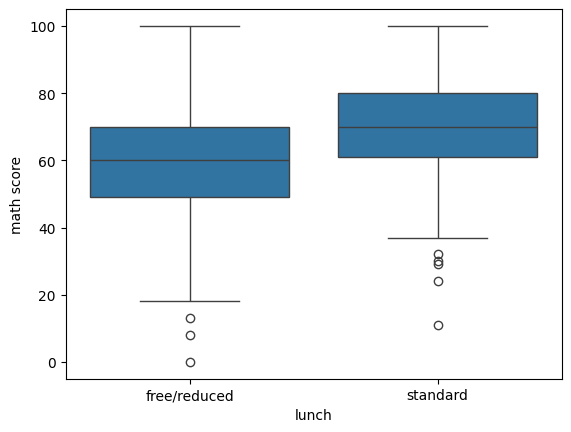

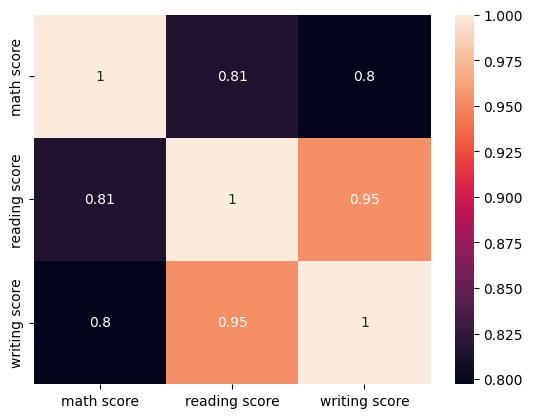

In [30]:
#Graphs

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='lunch', y='math score', data=df)
plt.show()

sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.show()